## **X4**: TT - Quantum Kernel SVM and the 67 Features
* October 6°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

Module 7 trained the same MLP on the five representations of Module 5. For C4 and C5 those representations are 12 numbers per lesion: the local Z expectations $\langle Z_i\rangle$ after a fixed ansatz (Architecture B, D-014). The MLP did clearly worse on them than on the classical representations (H-042).

That result mixes two things that this notebook separates:

1. **The encoding:** the quantum state $|\phi(\mathbf{x})\rangle$ that the feature map prepares, a vector of $2^{12}=4096$ amplitudes.
2. **The readout:** the 12 numbers $\langle Z_i\rangle$ that Architecture B keeps from that state.

The most direct quantum machine learning model on the encoding itself is a **quantum kernel support vector machine (QSVM)**. It is an ordinary SVM whose kernel is the fidelity $K_Q(\mathbf{x},\mathbf{x}')=|\langle\phi(\mathbf{x})|\phi(\mathbf{x}')\rangle|^2$, the same kernel analysed in Module 6. Comparing it with a classical SVM and with the MLP of Module 7 tells where the information is lost.

**Why the QSVM is the right reference among quantum models.** A variational quantum classifier with the same feature map computes $f(\mathbf{x})=\operatorname{Tr}(O_\theta\,\rho(\mathbf{x}))=\langle O_\theta,\rho(\mathbf{x})\rangle_{HS}$, a **linear** function of the density matrix $\rho(\mathbf{x})=|\phi(\mathbf{x})\rangle\langle\phi(\mathbf{x})|$. The kernel of that feature space is $\langle\rho(\mathbf{x}),\rho(\mathbf{x}')\rangle_{HS}=K_Q(\mathbf{x},\mathbf{x}')$. Every such classifier is therefore a function in the space that the QSVM searches whole, and Huang et al. (2021, p. 4 and Appendix C) state that the quantum kernel method can learn any such quantum neural network. Trained variational models can at most match the QSVM on the same encoding.

**A second question: the 67 features.** Could a quantum model gain an advantage if it received all 67 features of Module 3 instead of 12?

- The ZZ map would need 67 qubits, $2^{67}$ amplitudes: it cannot be simulated.
- Section 6° evaluates the two usual encodings that do admit 67 features and whose kernel can be computed exactly: **amplitude encoding**, in 7 qubits, and **product angle encoding**, one qubit per feature without entanglement. They are compared with a classical SVM on the same 67 features.

Everything uses the frozen folds of Module 4 (D-018, D-026). The official test split is used once per model, with a bootstrap by patient (D-036). The SVM is the same for every kernel: $C=1$ with balanced class weights (RF-19), no tuning. This is an exploratory analysis and does not change the design.

#### **1° Setup**

**a.** Libraries, parameters and data

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit
import sklearn
from qiskit import QuantumCircuit
from qiskit.circuit.library import pauli_feature_map, zz_feature_map
from qiskit.quantum_info import Statevector
from scipy.stats import rankdata
from sklearn.metrics import accuracy_score, f1_score, pairwise_distances, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
SEED, N_FOLDS, N_BOOT, C_SVM = 42, 5, 2000, 1.0
FINDINGS = ['mass', 'calcification']
TITLES = {'mass': 'Masses', 'calcification': 'Calcifications'}
SCALES = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02]
MULTIPLIERS = [0.25, 0.5, 1, 2, 4, 8, 16, 32, 64]          # the classical battery of D-032 (Huang et al., eq. L11)
SCALES_67 = [1.0, 0.2, 0.05, 0.02]
X_COLUMNS = [f'x_{i:02d}' for i in range(1, 13)]
ROOT = Path('/Users/alexander_san/TT')
M3_DIR, M4_DIR, M5_DIR, M7_DIR = (ROOT / f'Data/processed/m{i}' for i in (3, 4, 5, 7))
RESULTS_DIR, FIG_DIR = ROOT / 'Code/results', ROOT / 'Docs/Figures'
COLORS = {'C1': '#eda100', 'K_C': '#2a78d6', 'C4': '#eb6834', 'C5': '#1baf7a',
          'rbf 67': '#4a3aa7', 'amplitude 67': '#008300', 'product 67': '#e34948'}
INK = '#3d3d3a'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'lines.linewidth': 2, 'lines.markersize': 8})
maps = {'C4': zz_feature_map(12, reps=1), 'C5': pauli_feature_map(12, reps=1, paulis=['Y', 'ZZ'])}

data = {}
for ft in FINDINGS:
    d4 = pd.read_parquet(M4_DIR / f'x_{ft}.parquet')
    m3 = pd.read_parquet(M3_DIR / f'features_{ft}_raw.parquet').set_index('case_id').loc[d4.case_id]
    features67 = [c for c in m3.columns if c.startswith('original_')]
    data[ft] = {'frame': d4, 'X': d4[X_COLUMNS].to_numpy(float), 'X67': m3[features67].to_numpy(float),
                'y': d4.label.to_numpy(int), 'folds': d4.fold.to_numpy(int),
                'train': d4.split.eq('train').to_numpy(), 'test': d4.split.eq('test').to_numpy()}
    print(f"{ft:13s}: {int(data[ft]['train'].sum())} train and {int(data[ft]['test'].sum())} test lesions, "
          f"12 angles from Module 4 and {len(features67)} raw features from Module 3")
print(f'qiskit {qiskit.__version__} | scikit-learn {sklearn.__version__} | numpy {np.__version__}')

mass         : 1318 train and 378 test lesions, 12 angles from Module 4 and 67 raw features from Module 3
calcification: 1546 train and 326 test lesions, 12 angles from Module 4 and 67 raw features from Module 3
qiskit 2.3.0 | scikit-learn 1.7.2 | numpy 2.2.6


**b.** Kernels and the evaluation of an SVM with a precomputed kernel

The fidelity kernel is computed from the statevectors of all lesions: $K=|S^\dagger S|^2$, entry by entry. This is the same exact shortcut as `FidelityStatevectorKernel` (H-032), applied here to train and test at once. On hardware each entry would be estimated with shots. The SVM score is its decision function; the class prediction is its sign.

In [2]:
checks = []


def check(name, value, passed):
    checks.append({'check': name, 'value': float(value), 'passed': bool(passed)})


def fidelity_kernel(fm, X):
    S = np.array([Statevector(fm.assign_parameters(dict(zip(fm.parameters, x)))).data for x in X])
    return np.abs(S.conj() @ S.T) ** 2


def gaussian(X, gamma):
    return np.exp(-gamma * pairwise_distances(X, metric='sqeuclidean'))


def normalize_trace(K):
    # unit mean diagonal, like the Gaussian and fidelity kernels, so that C means the same for every kernel
    return K * len(K) / np.trace(K)


def median_gamma(X):
    sq = pairwise_distances(X, metric='sqeuclidean')
    return 1.0 / (2.0 * np.median(sq[np.triu_indices_from(sq, k=1)]))


def metrics(y, score):
    yhat = (score > 0).astype(int)
    return {'auc': roc_auc_score(y, score), 'f1': f1_score(y, yhat, zero_division=0), 'accuracy': accuracy_score(y, yhat),
            'precision': precision_score(y, yhat, zero_division=0), 'recall': recall_score(y, yhat, zero_division=0)}


def svm(K, d, test=True, C=C_SVM):
    # 5-fold CV on train with the frozen folds; then one fit on all of train, scored on test
    y, folds, tr, te = d['y'], d['folds'], d['train'], d['test']
    rows = []
    for f in range(N_FOLDS):
        a, b = tr & (folds != f), tr & (folds == f)
        m = SVC(kernel='precomputed', C=C, class_weight='balanced').fit(K[np.ix_(a, a)], y[a])
        rows.append({'fold': f, 'support_fraction': m.support_.size / a.sum(), **metrics(y[b], m.decision_function(K[np.ix_(b, a)]))})
    out = {'cv': pd.DataFrame(rows)}
    if test:
        m = SVC(kernel='precomputed', C=C, class_weight='balanced').fit(K[np.ix_(tr, tr)], y[tr])
        out['test_score'] = m.decision_function(K[np.ix_(te, tr)])
        out['test_support_fraction'] = m.support_.size / tr.sum()
    return out


print('Defined: fidelity_kernel, gaussian, normalize_trace, median_gamma, metrics, svm (CV with the frozen folds + one test fit)')

Defined: fidelity_kernel, gaussian, normalize_trace, median_gamma, metrics, svm (CV with the frozen folds + one test fit)


**c.** Check that the kernels computed here are the kernels of Module 5. On the 200 lesions of the subsample, the quantum kernel must equal the matrices of 5b, and the RBF bandwidth must equal the one of D-027.

In [3]:
for ft in FINDINGS:
    d = data[ft]
    z = np.load(M5_DIR / f'kernels_{ft}.npz', allow_pickle=True)
    pos = pd.Series(np.arange(len(d['frame'])), index=d['frame'].case_id).loc[z['case_id'].astype(str)].to_numpy()
    for q in ['C4', 'C5']:
        sub = fidelity_kernel(maps[q], d['X'][pos[:60]])
        err = np.abs(sub - z[f'K_Q_{q}'][:60, :60]).max()
        check(f'{ft}: {q} fidelity kernel equals Module 5 (60 x 60 block)', err, err < 1e-10)
    g = median_gamma(d['X'][d['train']])
    check(f'{ft}: RBF bandwidth equals D-027', abs(g - float(z['gamma'])), abs(g - float(z['gamma'])) < 1e-12)
    d['gamma'] = g
display(pd.DataFrame(checks))

,check,value,passed
0,mass: C4 fidelity kernel equals Module 5 (60 x...,8.659740e-15,True
1,mass: C5 fidelity kernel equals Module 5 (60 x...,1.021405e-14,True
2,mass: RBF bandwidth equals D-027,6.938894e-18,True
3,calcification: C4 fidelity kernel equals Modul...,1.287859e-14,True
4,calcification: C5 fidelity kernel equals Modul...,1.154632e-14,True
5,calcification: RBF bandwidth equals D-027,6.938894e-18,True


#### **2° QSVM against the classical SVM on the 12 angles**

**a.** The preregistered kernels: the fidelity kernels of C4 and C5 at $c=1$, and the RBF kernel of D-027

In [4]:
t0 = time.perf_counter()
results, kernels_c1 = {}, {}
for ft in FINDINGS:
    d = data[ft]
    results[(ft, 'SVM RBF (D-027)')] = svm(gaussian(d['X'], d['gamma']), d)
    for q in ['C4', 'C5']:
        K = fidelity_kernel(maps[q], d['X'])
        evals = np.linalg.eigvalsh(K[np.ix_(d['train'], d['train'])])
        check(f'{ft}: {q} train kernel is positive semidefinite', evals.min(), evals.min() > -1e-9)
        results[(ft, f'QSVM {q}, c = 1')] = svm(K, d)
print(f'preregistered kernels evaluated in {time.perf_counter() - t0:.0f} s')
rows = []
for (ft, model), r in results.items():
    cv = r['cv']
    rows.append({'finding_type': ft, 'model': model, 'cv_auc': cv.auc.mean(), 'cv_auc_sd': cv.auc.std(),
                 'cv_support_fraction': cv.support_fraction.mean(), 'test_auc': roc_auc_score(data[ft]['y'][data[ft]['test']], r['test_score'])})
display(pd.DataFrame(rows).round(3))

preregistered kernels evaluated in 60 s


,finding_type,model,cv_auc,cv_auc_sd,cv_support_fraction,test_auc
0,mass,SVM RBF (D-027),0.674,0.066,0.806,0.649
1,mass,"QSVM C4, c = 1",0.657,0.058,1.000,0.628
2,mass,"QSVM C5, c = 1",0.622,0.050,0.988,0.599
3,calcification,SVM RBF (D-027),0.746,0.023,0.682,0.769
4,calcification,"QSVM C4, c = 1",0.752,0.029,0.998,0.759
5,calcification,"QSVM C5, c = 1",0.706,0.019,0.970,0.701


**b.** The angle-scaling sweep (D-029) for the QSVM, and the classical battery of Module 6 (the linear kernel, normalized to trace $N$, and nine Gaussian widths), in cross-validation. The fraction of training lesions that the SVM keeps as support vectors shows memorization: when every lesion looks unrelated to every other one, the SVM has to keep almost all of them.

In [5]:
t0 = time.perf_counter()
sweep_rows = []
for ft in FINDINGS:
    d = data[ft]
    n, var = d['X'].shape[1], d['X'][d['train']].var()
    xc = d['X'] - d['X'][d['train']].mean(0)
    battery = {'linear': normalize_trace(xc @ xc.T)}
    battery.update({f'gaussian {m:g}': gaussian(d['X'], m / (n * var)) for m in MULTIPLIERS})
    for name, K in battery.items():
        cv = svm(K, d, test=False)['cv']
        sweep_rows.append({'finding_type': ft, 'family': 'classical', 'model': name, 'c': np.nan,
                           'cv_auc': cv.auc.mean(), 'cv_auc_sd': cv.auc.std(), 'support_fraction': cv.support_fraction.mean()})
    for q in ['C4', 'C5']:
        for c in SCALES:
            cv = (results[(ft, f'QSVM {q}, c = 1')]['cv'] if c == 1.0 else svm(fidelity_kernel(maps[q], c * d['X']), d, test=False)['cv'])
            sweep_rows.append({'finding_type': ft, 'family': 'quantum', 'model': f'QSVM {q}', 'c': c,
                               'cv_auc': cv.auc.mean(), 'cv_auc_sd': cv.auc.std(), 'support_fraction': cv.support_fraction.mean()})
sweep = pd.DataFrame(sweep_rows)
print(f'sweep and battery evaluated in {time.perf_counter() - t0:.0f} s')
display(sweep.assign(c=sweep.c.map(lambda v: '—' if pd.isna(v) else f'{v:g}')).round(3))

sweep and battery evaluated in 420 s


,finding_type,family,model,c,cv_auc,cv_auc_sd,support_fraction
0,mass,classical,linear,—,0.668,0.062,0.811
1,mass,classical,gaussian 0.25,—,0.672,0.066,0.809
2,mass,classical,gaussian 0.5,—,0.679,0.066,0.800
3,mass,classical,gaussian 1,—,0.682,0.065,0.794
4,mass,classical,gaussian 2,—,0.679,0.054,0.798
5,mass,classical,gaussian 4,—,0.665,0.037,0.821
6,mass,classical,gaussian 8,—,0.655,0.029,0.875
7,mass,classical,gaussian 16,—,0.643,0.031,0.945
8,mass,classical,gaussian 32,—,0.627,0.032,0.983
9,mass,classical,gaussian 64,—,0.603,0.032,0.997


**c.** Each family keeps its best kernel by cross-validated AUC, and that kernel is fitted once on train and scored on test. Both selections use the same folds, so both are equally optimistic.

In [6]:
best = {}
for ft in FINDINGS:
    d = data[ft]
    s = sweep[sweep.finding_type == ft]
    bc = s[s.family == 'classical'].sort_values('cv_auc', ascending=False).iloc[0]
    n, var = d['X'].shape[1], d['X'][d['train']].var()
    if bc.model == 'linear':
        xc = d['X'] - d['X'][d['train']].mean(0)
        Kc = normalize_trace(xc @ xc.T)
    else:
        Kc = gaussian(d['X'], float(bc.model.split()[1]) / (n * var))
    results[(ft, f'SVM classical best ({bc.model})')] = svm(Kc, d)
    for q in ['C4', 'C5']:
        bq = s[s.model == f'QSVM {q}'].sort_values('cv_auc', ascending=False).iloc[0]
        best[(ft, q)] = bq.c
        results[(ft, f'QSVM {q}, best c = {bq.c:g}')] = svm(fidelity_kernel(maps[q], bq.c * d['X']), d)
    print(f"{ft:13s}: best classical kernel {bc.model} (CV {bc.cv_auc:.3f}); best c for C4 = {best[(ft, 'C4')]:g}, for C5 = {best[(ft, 'C5')]:g}")

mass         : best classical kernel gaussian 1 (CV 0.682); best c for C4 = 0.05, for C5 = 0.05


calcification: best classical kernel gaussian 2 (CV 0.759); best c for C4 = 0.2, for C5 = 0.05


**d.** Sensitivity to the SVM regularization: $C=0.1$ and $C=10$ for the preregistered kernels, in cross-validation

In [7]:
c_rows = []
for ft in FINDINGS:
    d = data[ft]
    kernels = {'SVM RBF (D-027)': gaussian(d['X'], d['gamma'])}
    kernels.update({f'QSVM {q}, c = 1': fidelity_kernel(maps[q], d['X']) for q in ['C4', 'C5']})
    for name, K in kernels.items():
        for C in [0.1, 1.0, 10.0]:
            cv = svm(K, d, test=False, C=C)['cv']
            c_rows.append({'finding_type': ft, 'model': name, 'C': C, 'cv_auc': cv.auc.mean()})
c_table = pd.DataFrame(c_rows).pivot_table(index=['finding_type', 'model'], columns='C', values='cv_auc')
display(c_table.round(3))

C                               0.1    1.0    10.0
finding_type  model                               
calcification QSVM C4, c = 1   0.746  0.752  0.751
              QSVM C5, c = 1   0.715  0.706  0.691
              SVM RBF (D-027)  0.749  0.746  0.753
mass          QSVM C4, c = 1   0.651  0.657  0.654
              QSVM C5, c = 1   0.640  0.622  0.593
              SVM RBF (D-027)  0.657  0.674  0.688

#### **3° Where the information is lost: the encoding against the readout**

**a.** Test metrics with patient-bootstrap intervals for the SVMs and for the MLP of Module 7 on the same lesions. The MLP on C4 and C5 used the 12 readout values $\langle Z_i\rangle$; the QSVM uses the full state through its kernel.

In [8]:
def fast_auc(y, p):
    r = rankdata(p)
    n1 = y.sum()
    return (r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * (len(y) - n1))


mlp = pd.read_parquet(M7_DIR / 'predicciones.parquet')
mlp = mlp[(mlp.analysis == 'main') & (mlp.split == 'test')]
test_rows, boot = [], {}
for ft in FINDINGS:
    d = data[ft]
    te_frame = d['frame'][d['test']].reset_index(drop=True)
    y = te_frame.label.to_numpy(int)
    scores = {model: r['test_score'] for (f, model), r in results.items() if f == ft and 'test_score' in r}
    for cond in ['C1', 'C4', 'C5']:
        part = mlp[(mlp.finding_type == ft) & (mlp.condition == cond)].set_index('case_id').loc[te_frame.case_id]
        scores[f'MLP on {cond} (Module 7)'] = part.prob.to_numpy()
    patients = te_frame.patient_id.to_numpy()
    uniq, inv = np.unique(patients, return_inverse=True)
    members = [np.flatnonzero(inv == i) for i in range(len(uniq))]
    rng = np.random.default_rng(SEED)
    samples = [np.concatenate([members[i] for i in rng.integers(0, len(uniq), len(uniq))]) for _ in range(N_BOOT)]
    for model, s in scores.items():
        dist = np.array([fast_auc(y[idx], s[idx]) for idx in samples])
        boot[(ft, model)] = dist
        thresholded = metrics(y, s) if not model.startswith('MLP') else metrics(y, s - 0.5)
        test_rows.append({'finding_type': ft, 'model': model, **thresholded,
                          'auc_ci_low': np.percentile(dist, 2.5), 'auc_ci_high': np.percentile(dist, 97.5)})
test_table = pd.DataFrame(test_rows)
display(test_table.round(3))

,finding_type,model,auc,f1,accuracy,precision,recall,auc_ci_low,auc_ci_high
0,mass,SVM RBF (D-027),0.649,0.523,0.648,0.553,0.497,0.574,0.726
1,mass,"QSVM C4, c = 1",0.628,0.506,0.653,0.568,0.456,0.555,0.703
2,mass,"QSVM C5, c = 1",0.599,0.463,0.619,0.512,0.422,0.523,0.675
3,mass,SVM classical best (gaussian 1),0.658,0.495,0.616,0.507,0.483,0.587,0.732
4,mass,"QSVM C4, best c = 0.05",0.656,0.538,0.627,0.519,0.558,0.583,0.726
5,mass,"QSVM C5, best c = 0.05",0.650,0.526,0.619,0.510,0.544,0.576,0.720
6,mass,MLP on C1 (Module 7),0.651,0.519,0.638,0.536,0.503,0.578,0.724
7,mass,MLP on C4 (Module 7),0.530,0.386,0.529,0.392,0.381,0.473,0.587
8,mass,MLP on C5 (Module 7),0.581,0.456,0.571,0.450,0.463,0.521,0.644
9,calcification,SVM RBF (D-027),0.769,0.669,0.675,0.560,0.829,0.696,0.834


**b.** Paired differences in test AUC. *QSVM minus MLP on the same circuit* measures what the 12-number readout loses. *QSVM minus classical SVM* measures whether the quantum kernel adds anything over a classical kernel.

In [9]:
def differences(pairs):
    rows = []
    for ft in FINDINGS:
        for a, b in pairs:
            ka = next((k for k in boot if k[0] == ft and k[1].startswith(a)), None)
            kb = next((k for k in boot if k[0] == ft and k[1].startswith(b)), None)
            if ka is None or kb is None:
                continue
            dd = boot[ka] - boot[kb]
            rows.append({'finding_type': ft, 'comparison': f'{ka[1]} − {kb[1]}', 'mean_difference': dd.mean(),
                         'ci_low': np.percentile(dd, 2.5), 'ci_high': np.percentile(dd, 97.5), 'share_above_0': (dd > 0).mean()})
    return pd.DataFrame(rows)


pairs = [('QSVM C4, c = 1', 'MLP on C4'), ('QSVM C5, c = 1', 'MLP on C5'),
         ('QSVM C4, c = 1', 'SVM RBF (D-027)'), ('QSVM C5, c = 1', 'SVM RBF (D-027)'),
         ('QSVM C4, best', 'SVM classical best'), ('QSVM C5, best', 'SVM classical best'),
         ('SVM RBF (D-027)', 'MLP on C1')]
diff12 = differences(pairs)
display(diff12.round(3))

,finding_type,comparison,mean_difference,ci_low,ci_high,share_above_0
0,mass,"QSVM C4, c = 1 − MLP on C4 (Module 7)",0.099,0.025,0.171,0.994
1,mass,"QSVM C5, c = 1 − MLP on C5 (Module 7)",0.019,-0.057,0.092,0.694
2,mass,"QSVM C4, c = 1 − SVM RBF (D-027)",-0.021,-0.054,0.012,0.096
3,mass,"QSVM C5, c = 1 − SVM RBF (D-027)",-0.049,-0.093,-0.007,0.014
4,mass,"QSVM C4, best c = 0.05 − SVM classical best (g...",-0.002,-0.024,0.021,0.425
5,mass,"QSVM C5, best c = 0.05 − SVM classical best (g...",-0.009,-0.032,0.016,0.240
6,mass,SVM RBF (D-027) − MLP on C1 (Module 7),-0.002,-0.028,0.023,0.459
7,calcification,"QSVM C4, c = 1 − MLP on C4 (Module 7)",0.125,0.053,0.198,1.000
8,calcification,"QSVM C5, c = 1 − MLP on C5 (Module 7)",0.049,-0.017,0.115,0.927
9,calcification,"QSVM C4, c = 1 − SVM RBF (D-027)",-0.010,-0.041,0.023,0.262


**c.** Figures: the test AUC of every model, and the QSVM sweep of the angle scale with the fraction of support vectors

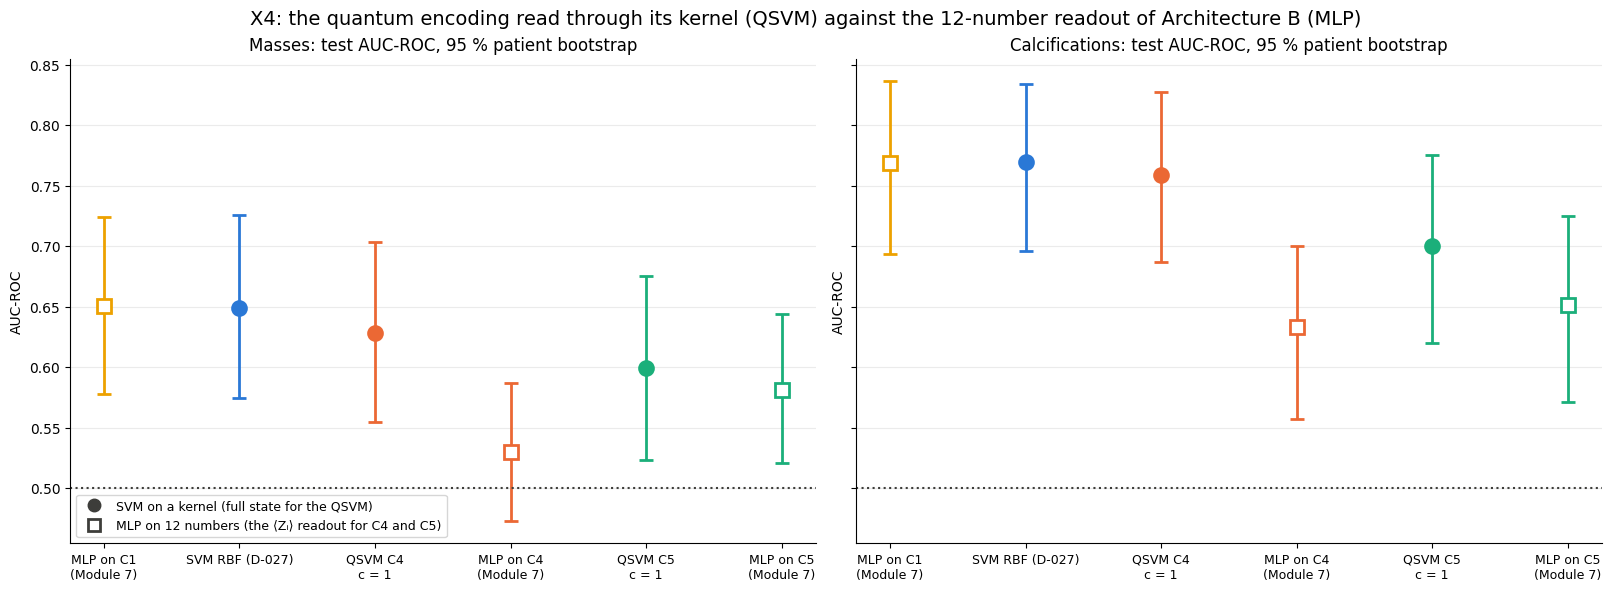

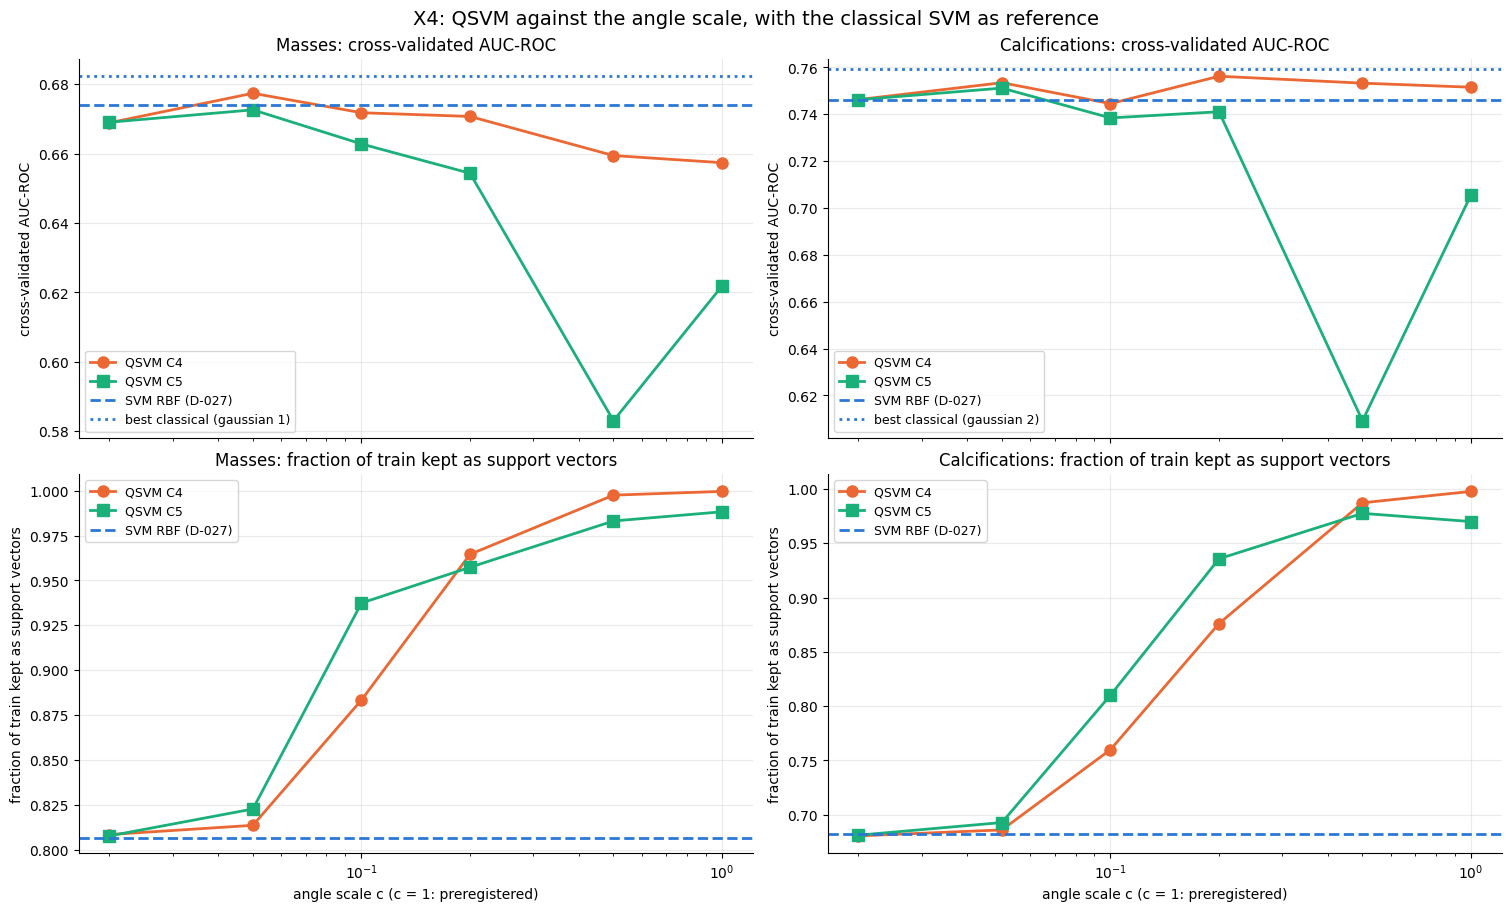

In [10]:
order = ['MLP on C1 (Module 7)', 'SVM RBF (D-027)', 'QSVM C4, c = 1', 'MLP on C4 (Module 7)', 'QSVM C5, c = 1', 'MLP on C5 (Module 7)']
color_of = {'MLP on C1 (Module 7)': COLORS['C1'], 'SVM RBF (D-027)': COLORS['K_C'], 'QSVM C4, c = 1': COLORS['C4'],
            'MLP on C4 (Module 7)': COLORS['C4'], 'QSVM C5, c = 1': COLORS['C5'], 'MLP on C5 (Module 7)': COLORS['C5']}
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8), constrained_layout=True, sharey=True)
for ax, ft in zip(axes, FINDINGS):
    t = test_table[test_table.finding_type == ft].set_index('model').loc[order]
    for i, model in enumerate(order):
        is_mlp = model.startswith('MLP')
        ax.errorbar(i, t.loc[model, 'auc'], yerr=[[t.loc[model, 'auc'] - t.loc[model, 'auc_ci_low']], [t.loc[model, 'auc_ci_high'] - t.loc[model, 'auc']]],
                    fmt='s' if is_mlp else 'o', markersize=10, capsize=5, color=color_of[model],
                    markerfacecolor='white' if is_mlp else color_of[model], markeredgewidth=2)
    ax.axhline(0.5, color=INK, ls=':', lw=1.5)
    ax.set_xticks(range(len(order)), [m.replace(' (Module 7)', '\n(Module 7)').replace(', c = 1', '\nc = 1') for m in order], fontsize=9)
    ax.grid(axis='x', visible=False)
    ax.set(title=f'{TITLES[ft]}: test AUC-ROC, 95 % patient bootstrap', ylabel='AUC-ROC')
handles = [plt.Line2D([], [], marker='o', ls='', color=INK, markersize=9, label='SVM on a kernel (full state for the QSVM)'),
           plt.Line2D([], [], marker='s', ls='', color=INK, markerfacecolor='white', markeredgewidth=2, markersize=9,
                      label='MLP on 12 numbers (the ⟨Zᵢ⟩ readout for C4 and C5)')]
axes[0].legend(handles=handles, fontsize=9, loc='lower left')
fig.suptitle('X4: the quantum encoding read through its kernel (QSVM) against the 12-number readout of Architecture B (MLP)', fontsize=14)
fig.savefig(FIG_DIR / 'X4_qsvm_vs_readout.png', dpi=180, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True, sharex=True)
markers = {'C4': 'o', 'C5': 's'}
for col, ft in enumerate(FINDINGS):
    s = sweep[sweep.finding_type == ft]
    cls = s[s.family == 'classical']
    for row, (ycol, label) in enumerate([('cv_auc', 'cross-validated AUC-ROC'), ('support_fraction', 'fraction of train kept as support vectors')]):
        ax = axes[row, col]
        for q in ['C4', 'C5']:
            p = s[s.model == f'QSVM {q}'].sort_values('c')
            ax.plot(p.c, p[ycol], marker=markers[q], color=COLORS[q], label=f'QSVM {q}')
        d027 = results[(ft, 'SVM RBF (D-027)')]['cv']
        ref = d027.auc.mean() if ycol == 'cv_auc' else d027.support_fraction.mean()
        ax.axhline(ref, color=COLORS['K_C'], ls='--', label='SVM RBF (D-027)')
        if ycol == 'cv_auc':
            ax.axhline(cls.cv_auc.max(), color=COLORS['K_C'], ls=':', label=f'best classical ({cls.sort_values("cv_auc").model.iloc[-1]})')
        ax.set(xscale='log', ylabel=label, title=f'{TITLES[ft]}: {label}')
        if row == 1:
            ax.set_xlabel('angle scale c (c = 1: preregistered)')
        ax.legend(fontsize=9)
fig.suptitle('X4: QSVM against the angle scale, with the classical SVM as reference', fontsize=14)
fig.savefig(FIG_DIR / 'X4_qsvm_scale.png', dpi=180, bbox_inches='tight')
plt.show()

#### **4° The 67 features**

**a.** Three kernels on the 67 raw features of Module 3, each scaled on train only:

- **Classical RBF.** Gaussian kernel on the standardized features, with the median-heuristic bandwidth of D-027.
- **Amplitude encoding.** The standardized vector, normalized to unit length and padded to 128 entries, is the amplitude vector of a 7-qubit state $|\mathbf{x}\rangle=\sum_k \hat x_k|k\rangle$. Its fidelity kernel is $|\langle\mathbf{x}|\mathbf{x}'\rangle|^2=(\hat{\mathbf{x}}\cdot\hat{\mathbf{x}}')^2$, the square of the cosine similarity. That is a classical polynomial kernel, the example with which Huang et al. open their paper (their eqs. 1 and 2).
- **Product angle encoding.** Each feature is turned into an angle in $[0,\pi]$ by the quantile rule of D-025 and rotates its own qubit, $R_Y(2x_i)|0\rangle$. There are 67 qubits and no entanglement, so the fidelity factorizes: $\prod_i\cos^2\!\big(c\,(x_i-x_i')\big)$. This is the first-order part of the ZZ map, which 5b found already extremely concentrated at 12 qubits.

Both formulas are first checked against Qiskit statevectors on small cases. A ZZ map on 67 qubits would need $2^{67}\approx1.5\times10^{20}$ amplitudes, and is beyond any simulator (OE-6).

In [11]:
def product_kernel(A, c):
    K = np.ones((len(A), len(A)))
    for i in range(A.shape[1]):
        K *= np.cos(c * (A[:, None, i] - A[None, :, i])) ** 2
    return K


# formula checks against Qiskit statevectors
rng = np.random.default_rng(SEED)
u = rng.normal(size=(4, 67))
u /= np.linalg.norm(u, axis=1, keepdims=True)
sv = [Statevector(np.pad(v, (0, 128 - 67))) for v in u]
err = max(abs(abs(sv[i].inner(sv[j])) ** 2 - (u[i] @ u[j]) ** 2) for i in range(4) for j in range(4))
check('amplitude encoding: fidelity = squared cosine similarity (7 qubits)', err, err < 1e-12)
a = rng.uniform(0, np.pi, size=(4, 6))


def ry_state(x):
    qc = QuantumCircuit(len(x))
    for q, v in enumerate(x):
        qc.ry(2 * v, q)
    return Statevector(qc)


err = max(abs(abs(ry_state(a[i]).inner(ry_state(a[j]))) ** 2 - product_kernel(a[[i, j]], 1.0)[0, 1]) for i in range(4) for j in range(4))
check('product angle encoding: fidelity = product of cos^2 (6 qubits)', err, err < 1e-12)

t0 = time.perf_counter()
rows67, kernels67 = [], {}
for ft in FINDINGS:
    d = data[ft]
    Z = StandardScaler().fit(d['X67'][d['train']]).transform(d['X67'])
    U = Z / np.linalg.norm(Z, axis=1, keepdims=True)
    A = np.pi * QuantileTransformer(n_quantiles=min(1000, int(d['train'].sum())), output_distribution='uniform',
                                    subsample=10**9, random_state=SEED).fit(d['X67'][d['train']]).transform(d['X67'])
    ks = {'SVM RBF, 67 features': gaussian(Z, median_gamma(Z[d['train']])), 'QSVM amplitude, 67 features (7 qubits)': (U @ U.T) ** 2}
    for c in SCALES_67:
        ks[f'QSVM product, 67 features (67 qubits), c = {c:g}'] = product_kernel(A, c)
    for name, K in ks.items():
        off = K[np.ix_(d['train'], d['train'])][~np.eye(int(d['train'].sum()), dtype=bool)]
        r = svm(K, d, test=False)
        rows67.append({'finding_type': ft, 'model': name, 'median_off_diagonal': np.median(off),
                       'cv_auc': r['cv'].auc.mean(), 'cv_auc_sd': r['cv'].auc.std(), 'support_fraction': r['cv'].support_fraction.mean()})
    kernels67[ft] = ks
table67 = pd.DataFrame(rows67)
print(f'67-feature kernels evaluated in {time.perf_counter() - t0:.0f} s')
display(table67.round(4))

67-feature kernels evaluated in 15 s


,finding_type,model,median_off_diagonal,cv_auc,cv_auc_sd,support_fraction
0,mass,"SVM RBF, 67 features",0.6065,0.6848,0.0612,0.8306
1,mass,"QSVM amplitude, 67 features (7 qubits)",0.1060,0.6396,0.0490,0.8461
2,mass,"QSVM product, 67 features (67 qubits), c = 1",0.0000,0.6107,0.0314,1.0000
3,mass,"QSVM product, 67 features (67 qubits), c = 0.2",0.0191,0.6894,0.0452,0.8277
4,mass,"QSVM product, 67 features (67 qubits), c = 0.05",0.7846,0.6790,0.0631,0.8323
5,mass,"QSVM product, 67 features (67 qubits), c = 0.02",0.9620,0.6584,0.0701,0.8917
6,calcification,"SVM RBF, 67 features",0.6065,0.7894,0.0206,0.6661
7,calcification,"QSVM amplitude, 67 features (7 qubits)",0.1118,0.7638,0.0286,0.7138
8,calcification,"QSVM product, 67 features (67 qubits), c = 1",0.0000,0.6479,0.0313,1.0000
9,calcification,"QSVM product, 67 features (67 qubits), c = 0.2",0.0197,0.7899,0.0259,0.6611


**b.** On test: the classical RBF on 67 features, the amplitude QSVM, and the product QSVM at its best scale by cross-validation, with paired differences against the classical SVMs on 67 and on 12 features

In [12]:
for ft in FINDINGS:
    d = data[ft]
    t = table67[table67.finding_type == ft]
    best_prod = t[t.model.str.startswith('QSVM product')].sort_values('cv_auc', ascending=False).model.iloc[0]
    for name in ['SVM RBF, 67 features', 'QSVM amplitude, 67 features (7 qubits)', best_prod]:
        results[(ft, name)] = svm(kernels67[ft][name], d)
    te_frame = d['frame'][d['test']].reset_index(drop=True)
    y = te_frame.label.to_numpy(int)
    patients = te_frame.patient_id.to_numpy()
    uniq, inv = np.unique(patients, return_inverse=True)
    members = [np.flatnonzero(inv == i) for i in range(len(uniq))]
    rng = np.random.default_rng(SEED)
    samples = [np.concatenate([members[i] for i in rng.integers(0, len(uniq), len(uniq))]) for _ in range(N_BOOT)]
    for name in ['SVM RBF, 67 features', 'QSVM amplitude, 67 features (7 qubits)', best_prod]:
        s = results[(ft, name)]['test_score']
        dist = np.array([fast_auc(y[idx], s[idx]) for idx in samples])
        boot[(ft, name)] = dist
        test_rows.append({'finding_type': ft, 'model': name, **metrics(y, s),
                          'auc_ci_low': np.percentile(dist, 2.5), 'auc_ci_high': np.percentile(dist, 97.5)})
test_table = pd.DataFrame(test_rows)
pairs67 = [('SVM RBF, 67 features', 'SVM RBF (D-027)'), ('QSVM amplitude', 'SVM RBF, 67 features'),
           ('QSVM product', 'SVM RBF, 67 features'), ('QSVM amplitude', 'SVM RBF (D-027)')]
diff67 = differences(pairs67)
display(test_table[test_table.model.str.contains('67')].round(3))
display(diff67.round(3))

,finding_type,model,auc,f1,accuracy,precision,recall,auc_ci_low,auc_ci_high
18,mass,"SVM RBF, 67 features",0.649,0.494,0.582,0.467,0.524,0.576,0.717
19,mass,"QSVM amplitude, 67 features (7 qubits)",0.599,0.469,0.587,0.469,0.469,0.531,0.664
20,mass,"QSVM product, 67 features (67 qubits), c = 0.2",0.645,0.540,0.616,0.506,0.578,0.574,0.712
21,calcification,"SVM RBF, 67 features",0.787,0.688,0.696,0.580,0.845,0.719,0.852
22,calcification,"QSVM amplitude, 67 features (7 qubits)",0.795,0.715,0.721,0.600,0.884,0.732,0.850
23,calcification,"QSVM product, 67 features (67 qubits), c = 0.2",0.750,0.675,0.699,0.590,0.791,0.677,0.820


,finding_type,comparison,mean_difference,ci_low,ci_high,share_above_0
0,mass,"SVM RBF, 67 features − SVM RBF (D-027)",-0.001,-0.033,0.030,0.474
1,mass,"QSVM amplitude, 67 features (7 qubits) − SVM R...",-0.050,-0.103,0.000,0.026
2,mass,"QSVM product, 67 features (67 qubits), c = 0.2...",-0.003,-0.042,0.039,0.426
3,mass,"QSVM amplitude, 67 features (7 qubits) − SVM R...",-0.051,-0.110,0.008,0.044
4,calcification,"SVM RBF, 67 features − SVM RBF (D-027)",0.019,-0.019,0.055,0.850
5,calcification,"QSVM amplitude, 67 features (7 qubits) − SVM R...",0.008,-0.028,0.045,0.649
6,calcification,"QSVM product, 67 features (67 qubits), c = 0.2...",-0.037,-0.072,-0.004,0.012
7,calcification,"QSVM amplitude, 67 features (7 qubits) − SVM R...",0.027,-0.021,0.079,0.856


**c.** Figure: cross-validated AUC of the 67-feature kernels, with the product encoding against the angle scale and the 12-angle RBF as reference

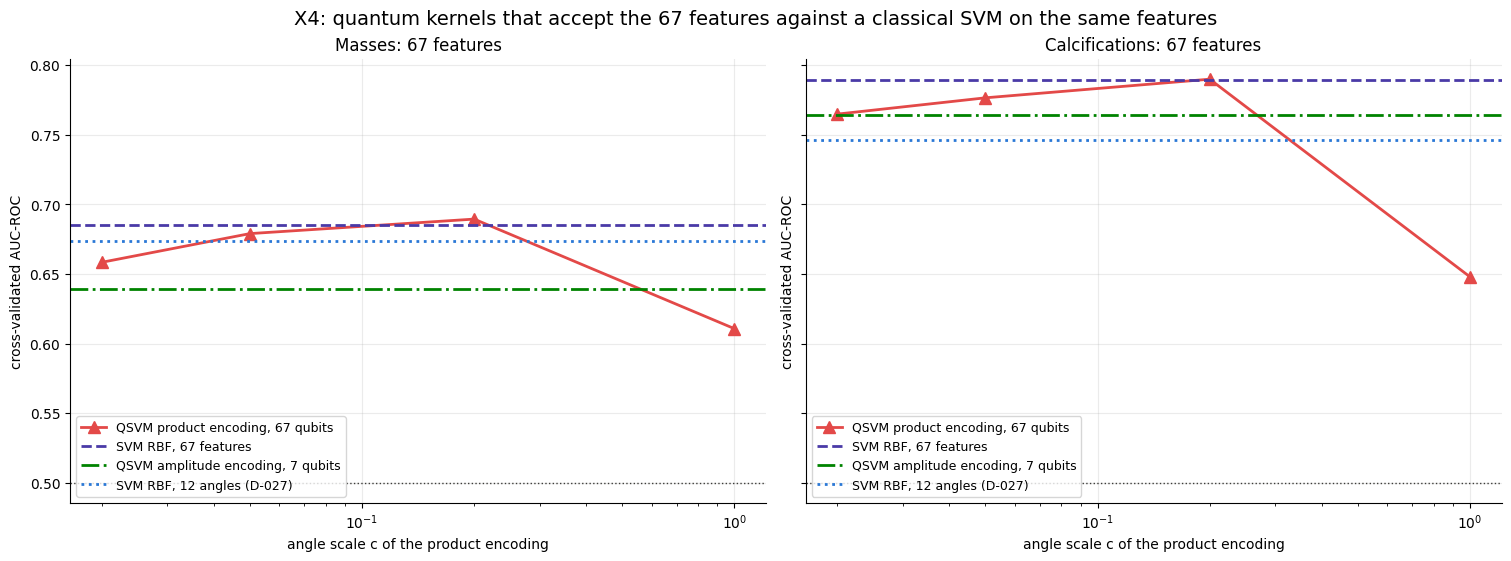

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True, sharey=True)
for ax, ft in zip(axes, FINDINGS):
    t = table67[table67.finding_type == ft]
    prod = t[t.model.str.startswith('QSVM product')].copy()
    prod['c'] = prod.model.str.split('c = ').str[1].astype(float)
    prod = prod.sort_values('c')
    ax.plot(prod.c, prod.cv_auc, marker='^', color=COLORS['product 67'], label='QSVM product encoding, 67 qubits')
    ax.axhline(t[t.model == 'SVM RBF, 67 features'].cv_auc.iloc[0], color=COLORS['rbf 67'], ls='--', label='SVM RBF, 67 features')
    ax.axhline(t[t.model.str.startswith('QSVM amplitude')].cv_auc.iloc[0], color=COLORS['amplitude 67'], ls='-.',
               label='QSVM amplitude encoding, 7 qubits')
    ax.axhline(results[(ft, 'SVM RBF (D-027)')]['cv'].auc.mean(), color=COLORS['K_C'], ls=':', label='SVM RBF, 12 angles (D-027)')
    ax.axhline(0.5, color=INK, ls=':', lw=1)
    ax.set(xscale='log', xlabel='angle scale c of the product encoding', ylabel='cross-validated AUC-ROC', title=f'{TITLES[ft]}: 67 features')
    ax.legend(fontsize=9, loc='lower left')
fig.suptitle('X4: quantum kernels that accept the 67 features against a classical SVM on the same features', fontsize=14)
fig.savefig(FIG_DIR / 'X4_67_features.png', dpi=180, bbox_inches='tight')
plt.show()

#### **5° Files and verifications**

In [14]:
cv_rows = []
for (ft, model), r in results.items():
    cv_rows.append(r['cv'].assign(finding_type=ft, model=model))
pd.concat(cv_rows, ignore_index=True).to_csv(RESULTS_DIR / 'X4_cv_por_fold.csv', index=False)
sweep.to_csv(RESULTS_DIR / 'X4_barrido_y_bateria.csv', index=False)
c_table.reset_index().to_csv(RESULTS_DIR / 'X4_sensibilidad_C.csv', index=False)
test_table.to_csv(RESULTS_DIR / 'X4_test.csv', index=False)
pd.concat([diff12, diff67], ignore_index=True).to_csv(RESULTS_DIR / 'X4_test_diferencias.csv', index=False)
table67.to_csv(RESULTS_DIR / 'X4_67_features.csv', index=False)
verifications = pd.DataFrame(checks)
verifications.to_csv(RESULTS_DIR / 'X4_verificaciones.csv', index=False)
display(verifications)
print(f'Checks passed: {int(verifications.passed.sum())}/{len(verifications)}')

,check,value,passed
0,mass: C4 fidelity kernel equals Module 5 (60 x...,8.659740e-15,True
1,mass: C5 fidelity kernel equals Module 5 (60 x...,1.021405e-14,True
2,mass: RBF bandwidth equals D-027,6.938894e-18,True
3,calcification: C4 fidelity kernel equals Modul...,1.287859e-14,True
4,calcification: C5 fidelity kernel equals Modul...,1.154632e-14,True
5,calcification: RBF bandwidth equals D-027,6.938894e-18,True
6,mass: C4 train kernel is positive semidefinite,1.644541e-01,True
7,mass: C5 train kernel is positive semidefinite,1.345549e-01,True
8,calcification: C4 train kernel is positive sem...,1.700436e-01,True
9,calcification: C5 train kernel is positive sem...,1.701474e-01,True


Checks passed: 12/12


#### **6° Consequence**

**1. The quantum encoding holds almost as much class information as a classical kernel; the 12-number readout loses it.**

| Test AUC-ROC [95 % patient bootstrap] | Masses | Calcifications |
|---|---|---|
| SVM RBF (D-027) | 0.649 [0.57, 0.73] | 0.769 [0.70, 0.83] |
| QSVM C4, $c=1$ | 0.628 [0.55, 0.70] | 0.759 [0.69, 0.83] |
| MLP on the $\langle Z_i\rangle$ of C4 (Module 7) | 0.530 [0.47, 0.59] | 0.633 [0.56, 0.70] |

- **QSVM against MLP on the same circuit.** The difference is +0.10 [0.03, 0.17] in masses and +0.13 [0.05, 0.20] in calcifications. The fidelity kernel compares the whole 4,096-amplitude state, phases included; the MLP received 12 local Z expectations after a fixed ansatz. **Most of the loss of Module 7 comes from Architecture B's readout, not from the feature map.** It is the most concrete instance of H-013.
- **QSVM C4 against the classical SVM.** The difference is −0.02 [−0.05, 0.01] in masses and −0.01 [−0.04, 0.02] in calcifications: indistinguishable.
- **Why global metrics hid this.** The QSVM keeps practically every training lesion as a support vector (support fraction 1.00 in masses, 0.998 in calcifications), as expected from a kernel close to the identity. It decides from the few lesions whose encoded states do overlap, a local structure. The global alignment and pair AUC of Module 6 average over every pair, and that structure is too sparse for them to see (H-036, limits).

**2. No quantum kernel goes beyond the classical one.**

- **Choosing the angle scale by cross-validation** brings C4 to the level of the best classical kernel on test: −0.002 [−0.02, 0.02] in masses ($c=0.05$) and −0.005 [−0.03, 0.02] in calcifications ($c=0.2$). That is equivalence, not advantage. At those scales the kernel no longer uses the product term (H-031).
- **C5** is significantly below the classical kernel at $c=1$: −0.05 [−0.09, −0.01] in masses and −0.07 [−0.12, −0.02] in calcifications. Its kernel is the most concentrated one (H-037).
- **The regularization $C$** of the SVM does not change any of this.

This is exactly what the geometric difference predicted. The result of Huang et al. concerns kernel methods: with $g\approx1.4\ll\sqrt{N}$, a classical kernel is competitive with the quantum kernel method for any labels.

**3. The 67 features do not open an advantage either.**

- **Classical ceiling.** The classical SVM on all 67 features gains nothing in masses (−0.001) and +0.02 [−0.02, 0.06] in calcifications. The extra information is small, as X1 found.
- **Amplitude encoding (7 qubits).** Its kernel is exactly the square of the cosine similarity, a classical polynomial kernel of degree 2, checked to $2\times10^{-16}$. It reaches the highest test AUC of the notebook in calcifications, 0.795 [0.73, 0.85], but that is not quantum: it is computable classically in microseconds, and it is not significantly above the RBF (+0.008 [−0.03, 0.05]). In masses it is below (−0.05 [−0.10, 0.00]).
- **Product angle encoding (67 qubits).** At $c=1$ its kernel is completely concentrated: the median off-diagonal value is 0.0000 and every lesion is a support vector. When the angles are reduced, $\prod_i\cos^2(c\,\Delta_i)\approx\exp(-c^2\lVert\Delta\rVert^2)$ becomes a Gaussian kernel, and its AUC becomes that of the classical RBF. A quantum kernel that is not classically computable on 67 features, such as a 67-qubit ZZ map, would need $2^{67}$ amplitudes and cannot be simulated.

**4. Answer.**

- A quantum model applied directly to the encoding (QSVM) does better than the MLP of Module 7, because it avoids the lossy readout.
- It only matches the classical kernel methods; it never exceeds them.
- Neither more features nor the alternative encodings change that.

This refines the reading of Modules 6 and 7 without changing the answer to OE-3.


In [15]:
print('=' * 92)
print('X4 - QSVM AND THE 67 FEATURES - SUMMARY (test AUC-ROC with 95 % patient bootstrap)')
print('=' * 92)
for ft in FINDINGS:
    t = test_table[test_table.finding_type == ft].set_index('model')
    print(f'  {TITLES[ft]}')
    for model in t.index:
        print(f"    {model:52s} {t.loc[model, 'auc']:.3f} [{t.loc[model, 'auc_ci_low']:.2f}, {t.loc[model, 'auc_ci_high']:.2f}]")
print(f"  Checks passed: {int(verifications.passed.sum())}/{len(verifications)}")
print('=' * 92)

X4 - QSVM AND THE 67 FEATURES - SUMMARY (test AUC-ROC with 95 % patient bootstrap)
  Masses
    SVM RBF (D-027)                                      0.649 [0.57, 0.73]
    QSVM C4, c = 1                                       0.628 [0.55, 0.70]
    QSVM C5, c = 1                                       0.599 [0.52, 0.68]
    SVM classical best (gaussian 1)                      0.658 [0.59, 0.73]
    QSVM C4, best c = 0.05                               0.656 [0.58, 0.73]
    QSVM C5, best c = 0.05                               0.650 [0.58, 0.72]
    MLP on C1 (Module 7)                                 0.651 [0.58, 0.72]
    MLP on C4 (Module 7)                                 0.530 [0.47, 0.59]
    MLP on C5 (Module 7)                                 0.581 [0.52, 0.64]
    SVM RBF, 67 features                                 0.649 [0.58, 0.72]
    QSVM amplitude, 67 features (7 qubits)               0.599 [0.53, 0.66]
    QSVM product, 67 features (67 qubits), c = 0.2       0.645 [0.57, 0.